In [33]:
import os
import sys

import argparse
from color_analysis_tool import ImageAnalyzer, ImageInfo
#from matplotlib.colors import rgb_to_hsv
from tqdm import tqdm
import numpy as np
from scipy.stats import wasserstein_distance_nd

import matplotlib.pyplot as plt

import torch
from torchvision.io import read_image
from torchvision.transforms import v2 as transforms
import torchvision.transforms.functional as F

In [34]:
# For some reason, the function from matplotlib doesn't work
def rgb_to_hsv(arr):
    """
    Convert an array of float RGB values (in the range [0, 1]) to HSV values.

    Parameters
    ----------
    arr : (..., 3) array-like
       All values must be in the range [0, 1]

    Returns
    -------
    (..., 3) `~numpy.ndarray`
       Colors converted to HSV values in range [0, 1]
    """
    arr = np.asarray(arr)

    # check length of the last dimension, should be _some_ sort of rgb
    if arr.shape[-1] != 3:
        raise ValueError("Last dimension of input array must be 3; "
                         f"shape {arr.shape} was found.")

    in_shape = arr.shape
    arr = np.array(
        arr,
        dtype=np.promote_types(arr.dtype, np.float32),  # Don't work on ints.
        ndmin=2,  # In case input was 1D.
    )

    out = np.zeros_like(arr)
    arr_max = arr.max(-1)
    # Check if input is in the expected range
    if np.any(arr_max > 1):
        raise ValueError(
            "Input array must be in the range [0, 1]. "
            f"Found a maximum value of {arr_max.max()}"
        )

    if arr.min() < 0:
        raise ValueError(
            "Input array must be in the range [0, 1]. "
            f"Found a minimum value of {arr.min()}"
        )

    ipos = arr_max > 0
    delta = np.ptp(arr, -1)
    s = np.zeros_like(delta)
    s[ipos] = delta[ipos] / arr_max[ipos]
    ipos = delta > 0
    # red is max
    idx = (arr[..., 0] == arr_max) & ipos
    out[idx, 0] = (arr[idx, 1] - arr[idx, 2]) / delta[idx]
    # green is max
    idx = (arr[..., 1] == arr_max) & ipos
    out[idx, 0] = 2. + (arr[idx, 2] - arr[idx, 0]) / delta[idx]
    # blue is max
    idx = (arr[..., 2] == arr_max) & ipos
    out[idx, 0] = 4. + (arr[idx, 0] - arr[idx, 1]) / delta[idx]

    out[..., 0] = (out[..., 0] / 6.0) % 1.0
    out[..., 1] = s
    out[..., 2] = arr_max

    return out.reshape(in_shape)

In [35]:
def analyse_colors(image_path, palette_size):
    analyzer = ImageAnalyzer()
    return analyzer.analyze_image(image_path, max_colors=palette_size)

In [36]:
# Convert analysis result to a tuple of values/weights
def to_distribution(info: ImageInfo):
    values = []
    weights = []
    for color in info.colors:
        (r,g,b) = color.rgb
        values.append([r / 255.0, g / 255.0, b / 255.0])
        weights.append(color.frequency)
    return (values, weights)

In [37]:
# TODO: similarity instead of distance
def compute_distance(image_path_a, image_path_b, palette_size):
    info_a = analyse_colors(image_path_a, palette_size)
    (colors_a, weights_a) = to_distribution(info_a)
    info_b = analyse_colors(image_path_b, palette_size)
    (colors_b, weights_b) = to_distribution(info_b)
    distance = wasserstein_distance_nd(colors_a, colors_b, weights_a, weights_b)
    return (info_a, info_b, distance)

In [38]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')

def image_transform(test=False):
    # normalize = transforms.Normalize(
    #     mean=[0.4914, 0.4822, 0.4465],
    #     std=[0.2023, 0.1994, 0.2010],
    # )
    mid_transforms = [
    ] if test else [
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomVerticalFlip(),
        #transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
        #transforms.ColorJitter(),
        # transforms.GaussianBlur(5),
    ]
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
    ] + mid_transforms + [
        transforms.Resize((224,224)),
        # normalize,
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])


def load_image(path):
    transform = image_transform(test=True)
    image = read_image(path)
    image = transform(image)
    return image

In [39]:
def load_paths(root_dir) -> list:
    filenames = next(os.walk(root_dir), (None, None, []))[2]
    return [os.path.join(root_dir, filename) for filename in filenames]

Analyzing colors: 100%|██████████| 8/8 [00:00<00:00, 58764.33it/s]


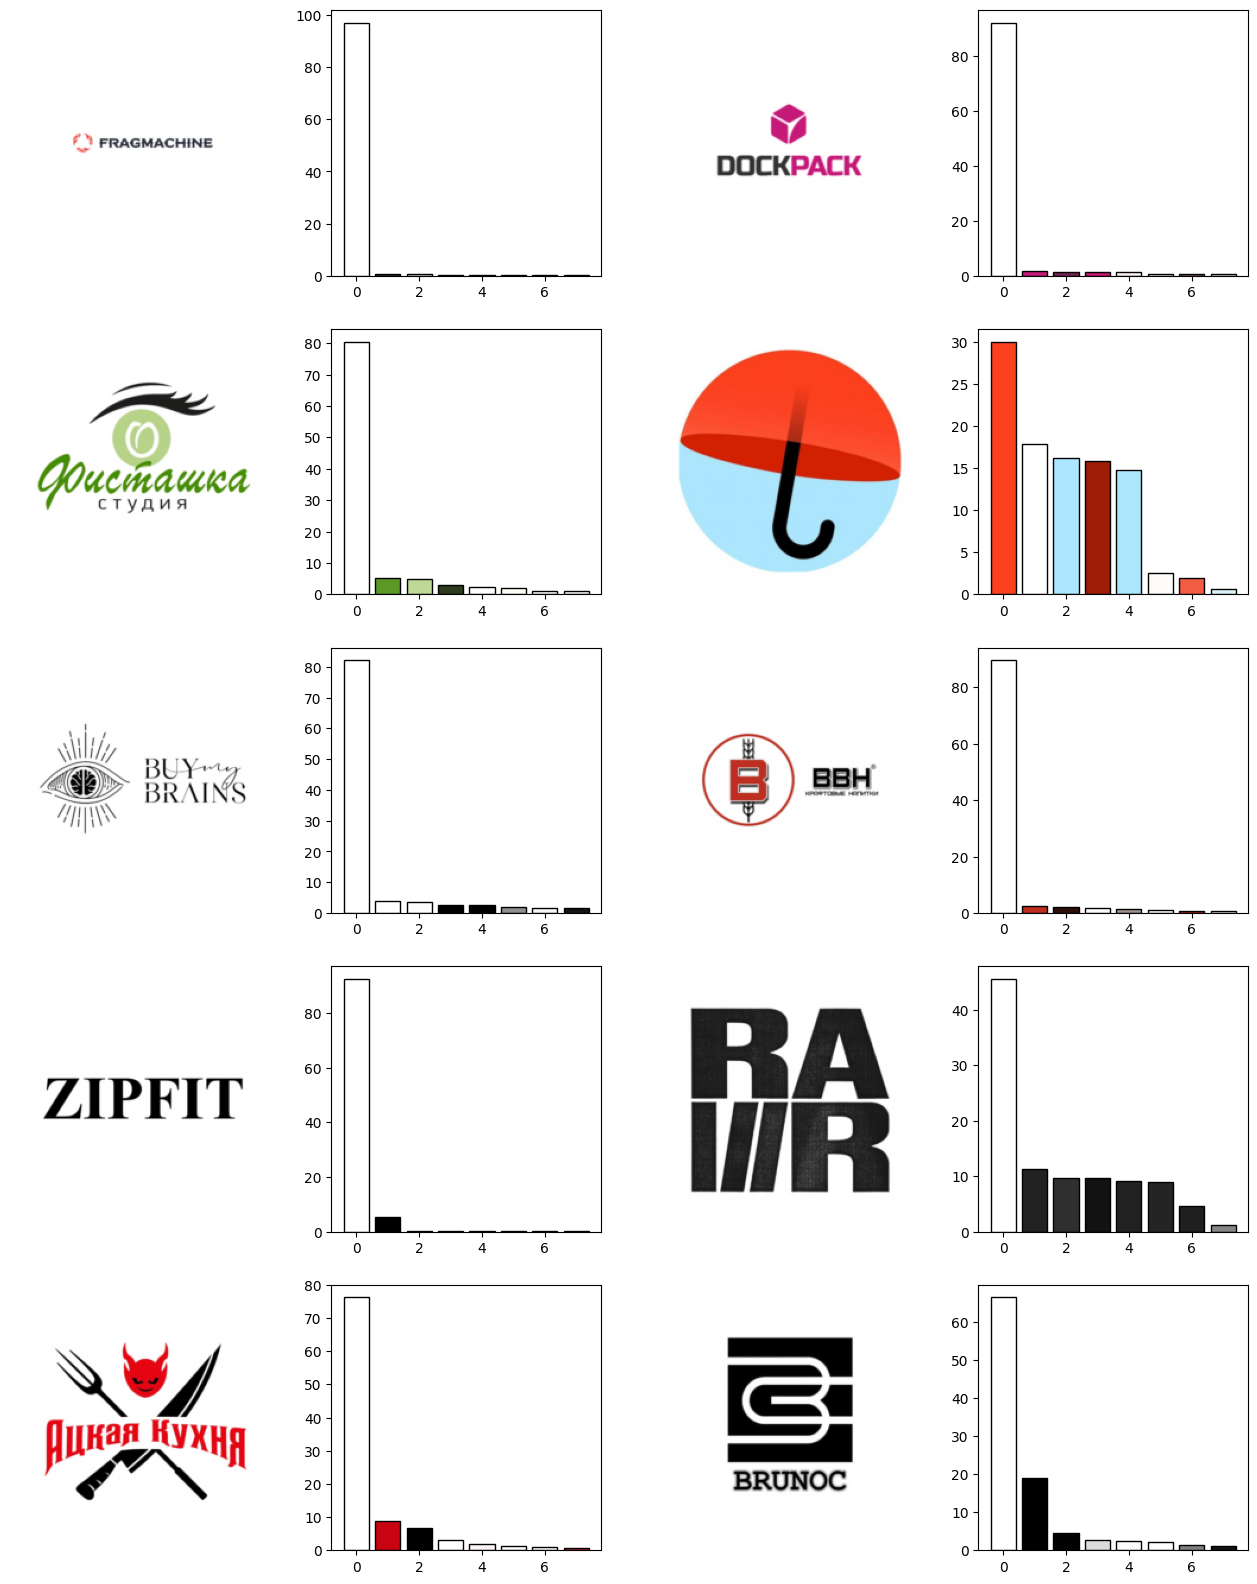

In [40]:
w, h = 4, 5
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths('../data/logos-old/')

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

for i, ax_row in enumerate(axs):
    for j, ax in enumerate(ax_row):
        img_path = image_paths[i * (w // 2) + j // 2]
        img = load_image(img_path)
        if j % 2 == 0: # Image
            ax.set_axis_off()
            ax.imshow(img.transpose(0,1).transpose(1,2))
        else: # Color palette
            info = analyse_colors(img_path, 8)
            colors, weights = to_distribution(info)
            ax.bar(range(len(weights)), weights, color=colors, edgecolor='0')

plt.show()

Analyzing colors: 100%|██████████| 8/8 [00:00<00:00, 52675.72it/s]


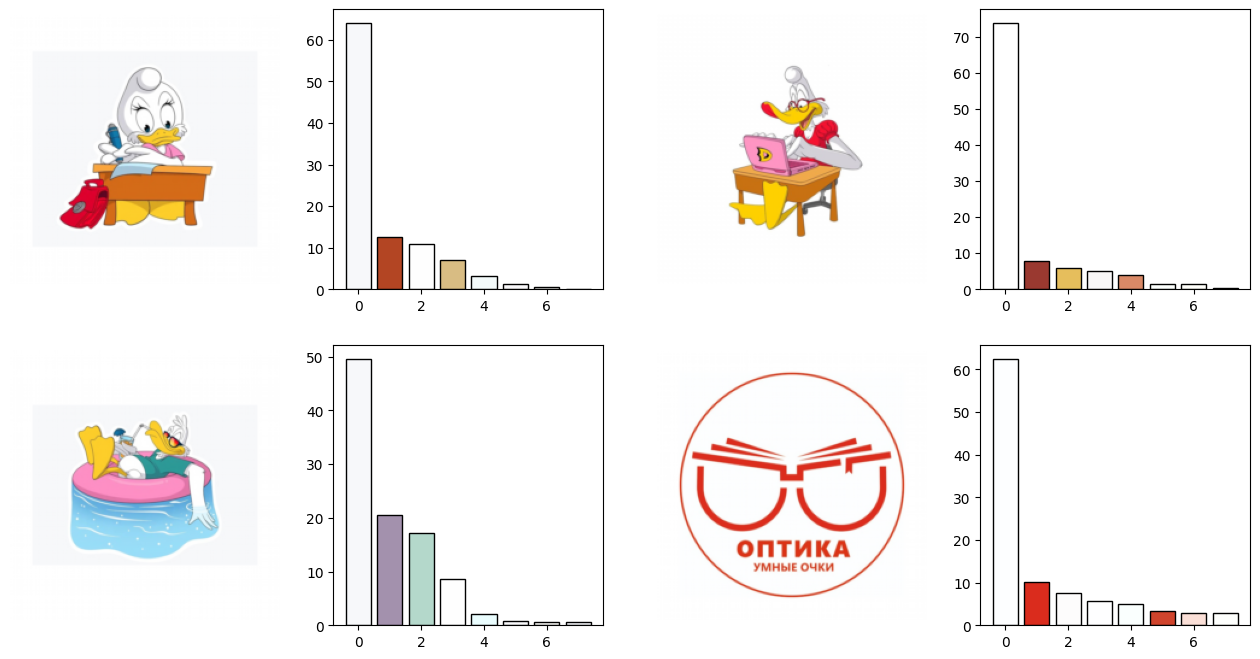

In [41]:
w, h = 4, 2
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

image_paths = [
    '../data/logos/1014250.jpg',
    '../data/logos/1001179.jpg',
    '../data/logos/1000349.jpg',
    '../data/logos/1076759.jpg',
]

for i, ax_row in enumerate(axs):
    for j, ax in enumerate(ax_row):
        idx = i * (w // 2) + j // 2
        if idx >= len(image_paths):
            break
        img_path = image_paths[idx]
        img = load_image(img_path)
        if j % 2 == 0: # Image
            ax.set_axis_off()
            ax.imshow(img.transpose(0,1).transpose(1,2))
        else: # Color palette
            info = analyse_colors(img_path, 8)
            colors, weights = to_distribution(info)
            ax.bar(range(len(weights)), weights, color=colors, edgecolor='0')

plt.show()

In [42]:
palette_size = 8

def show_similarity(path_a, path_b):
    w, h = 4, 1
    _, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

    _, _, distance = compute_distance(path_a, path_b, palette_size)
    similarity = 1.0 / (1.0 + distance)
    print()
    print(f'Distance: {distance}')
    print(f'Similarity: {similarity * 100.0:.2f}%')
    print()

    image_paths = [path_a, path_b]

    i = 0
    for j, ax in enumerate(axs):
        idx = i * (w // 2) + j // 2
        if idx >= len(image_paths):
            break
        img_path = image_paths[idx]
        img = load_image(img_path)
        if j % 2 == 0: # Image
            ax.set_axis_off()
            ax.imshow(img.transpose(0,1).transpose(1,2))
        else: # Color palette
            info = analyse_colors(img_path, 8)
            colors, weights = to_distribution(info)
            ax.bar(range(len(weights)), weights, color=colors, edgecolor='0')

    plt.show()

Analyzing colors: 100%|██████████| 8/8 [00:00<00:00, 48210.39it/s]



Distance: 0.07949738402806379
Similarity: 92.64%



Analyzing colors: 100%|██████████| 8/8 [00:00<00:00, 49932.19it/s]


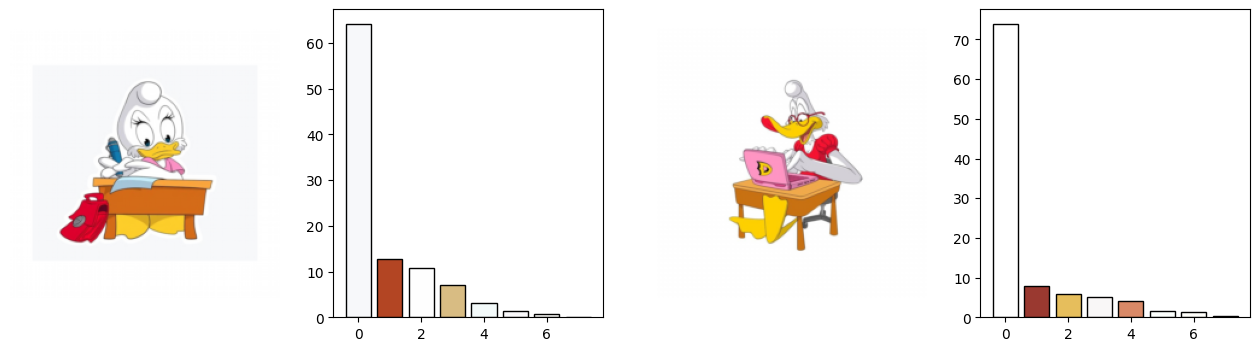

In [43]:
show_similarity('../data/logos/1014250.jpg', '../data/logos/1001179.jpg')

Analyzing colors: 100%|██████████| 8/8 [00:00<00:00, 52347.01it/s]



Distance: 0.08271758264862682
Similarity: 92.36%



Analyzing colors: 100%|██████████| 8/8 [00:00<00:00, 51385.04it/s]


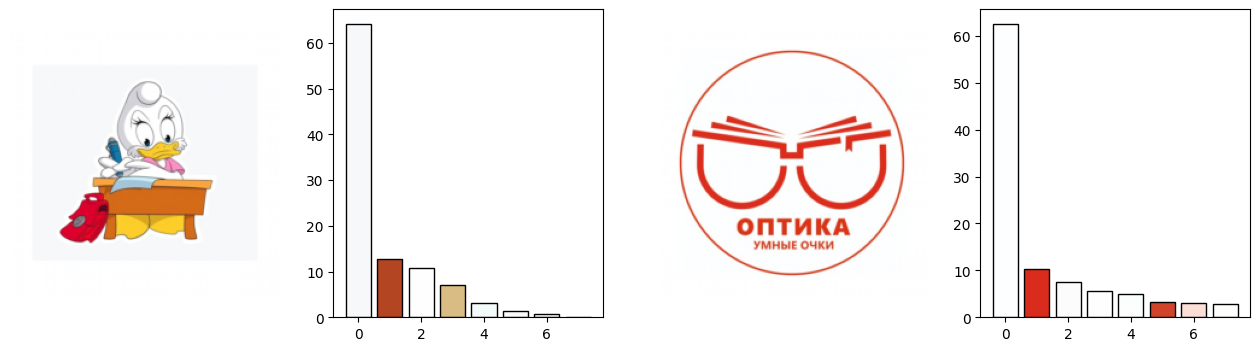

In [45]:
show_similarity('../data/logos/1014250.jpg', '../data/logos/1076759.jpg')

Analyzing colors: 100%|██████████| 8/8 [00:00<00:00, 35925.52it/s]



Distance: 0.03712404317204568
Similarity: 96.42%



Analyzing colors: 100%|██████████| 8/8 [00:00<00:00, 38836.15it/s]


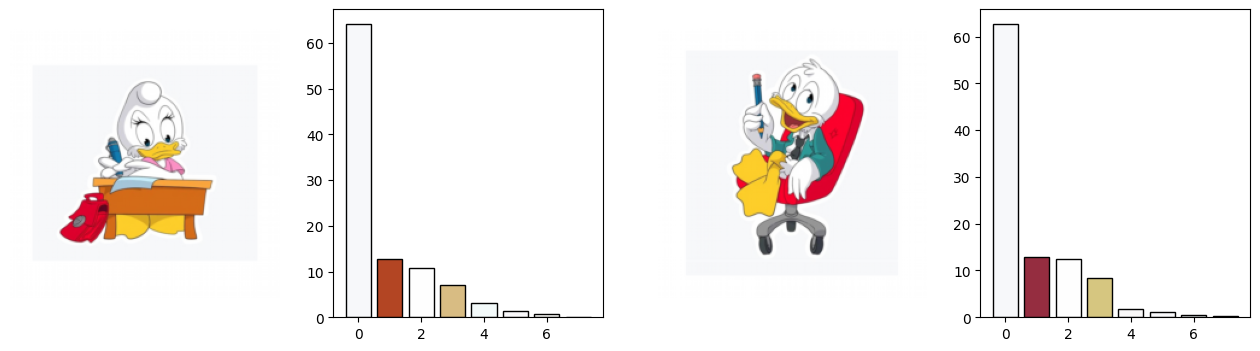

In [46]:
show_similarity('../data/logos/1014250.jpg', '../data/logos/1005234.jpg')